# Research attention to direct drivers differs across ecosystem realms

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis.realm import driver as driver_realm
from data_helpers.analysis.realm import driver_plotting as driver_realm_plotting
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
REALM_CONFIG = RESULTS_CONFIG["driver_realm"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
DRIVER_CATALOG, DRIVER_COLORS, DRIVER_NAMES = results_config.driver_l1_display(
    RESULTS_CONFIG
)
DRIVER_ORDER = tuple(results_config.driver_l1_stack_order(RESULTS_CONFIG))

CORE_REALMS = tuple(REALM_CONFIG["core_realms"])
REALM_NAMES = REALM_CONFIG["realm_display_names"]
REALM_SHORT_NAMES = REALM_CONFIG["realm_short_names"]
START_YEAR = REALM_CONFIG["primary_start_year"]
END_YEAR = REALM_CONFIG["primary_end_year"]
CORE_REALM_COLORS = {
    "Terrestrial": "#E69F00",
    "Freshwater": "#009E73",
    "Marine": "#0072B2",
}

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

OUTPUT_DIR = PROJECT_ROOT / REALM_CONFIG["output_directory"]
TABLE_DIR = OUTPUT_DIR / REALM_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / REALM_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Provenance: the complete set of inputs this result depends on.
status = "found" if CORPUS_DIR.exists() else "MISSING"
print(f"Input   dataset  {CORPUS_DIR.relative_to(PROJECT_ROOT)}  [{status}]")
if not CORPUS_DIR.exists():
    raise FileNotFoundError(
        "Run notebooks/data_processing/04_dataset.ipynb first."
    )
print(f"Output section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


def save_table(table, filename, index=False):
    path = TABLE_DIR / f"{filename}.csv"
    table.to_csv(path, index=index)
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
    return path


def save_figure(figure, filename):
    return visualization.save_figure(
        figure, FIGURE_DIR / filename, formats=["pdf"], dpi=300, pad_inches=0.05
    )

Input   dataset  notebooks/data_processing/outputs/04_dataset  [found]
Output section: notebooks/results/outputs/03_realm_composition


## 1. Dataset

Based on core 253k dataset of biodiversity loss, dataset has labels for IPBES Drivers and Realms. Here each loaded for this analysis.

**Realms**: Only the 3 core realms (Terrestrial, Freshwater, Marine) are loaded. Records without exactly one core realm are excluded (Not Applicable, All realms, multiple labels, or a transition/subterranean realms).

**IPBES Drivers**: Load all records check for any exclusions to be made

In [5]:
corpus_store = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR)
corpus_df = corpus_store.load(
    columns=[
        "UT", "title", "publication_year", "s2_dir", "driver", "realm",
        "text_available", "plastics_mention",
    ]
).publications
prepared = driver_realm.prepare_realm_evidence(
    corpus_df,
    analysis_realms=CORE_REALMS,
    direction=REALM_CONFIG["direction"],
    start_year=START_YEAR,
    end_year=END_YEAR,
)
realm_counts = driver_realm.realm_counts(prepared.evidence)
realm_supports = realm_counts.set_index("realm")["n_documents"].to_dict()

audit = prepared.audit.set_index("metric")["value"]
n_negative = audit[f"Publications with direction = {REALM_CONFIG['direction']}"]
n_in_window = audit[f"Direction-filtered publications in {START_YEAR}–{END_YEAR}"]
n_outside_window = audit["Direction-filtered publications outside window or missing year"]
n_realm_final = audit["Realm audit — Exact singleton analysis realm"]

print(
    f"Core data loaded: {n_negative:,}"
    "(biodiversity-loss evidence)"
)
print(
    f"  {n_in_window:,} fall within {START_YEAR}-{END_YEAR}; "
    f"{n_outside_window:,} fall outside the window or have no year"
)
print()
print(f"Realm labels analyzed ({len(CORE_REALMS)}): {', '.join(CORE_REALMS)}")
print()
print("Excluded from realm analysis:")
display(
    prepared.realm_exclusions.rename(
        columns={"realm_category": "reason", "n_documents": "excluded"}
    )
)
print(f"Final: {n_realm_final:,} publications with exactly one core realm")

Core data loaded: 253,081(biodiversity-loss evidence)
  245,168 fall within 2000-2025; 7,913 fall outside the window or have no year

Realm labels analyzed (3): Terrestrial, Freshwater, Marine

Excluded from realm analysis:


,reason,excluded
0,Excluded realm: Not Applicable,11858
1,Excluded realm: Freshwater-Marine,8492
2,Excluded realm: Marine-Terrestrial,3195
3,Excluded realm: Freshwater-Terrestrial,2567
4,Excluded realm: Subterranean-Freshwater,1117
5,Excluded realm: Subterranean,1047
6,Excluded realm: All realms,613
7,Excluded realm: Marine-Freshwater-Terrestrial,399
8,Multiple realm labels,314
9,Excluded realm: Subterranean-Marine,36


Final: 215,530 publications with exactly one core realm


In [6]:
driver_summary = driver_realm.driver_realm_summary(prepared.evidence)

n_driver_excluded = audit["Analysis-realm publications without a usable driver"]
n_driver_final = audit["Analysis publications"]
n_multi_driver = audit["Multi-driver analysis publications"]
n_driver_tags = audit["Unique document–driver assignments"]

print(
    f"Core data loaded: {n_realm_final:,} realm-resolved publications "
    "carry forward into driver assignment"
)
print()
print(f"IPBES L1 drivers analyzed ({len(DRIVER_ORDER)}): {', '.join(DRIVER_ORDER)}")
print()
print("Excluded from driver analysis:")
display(
    pd.DataFrame([{"reason": "No usable driver label", "excluded": n_driver_excluded}])
)
print(
    f"Final: {n_driver_final:,} publications with at least one driver "
    f"({n_multi_driver:,} carry more than one; {n_driver_tags:,} total document–driver tags)"
)

Core data loaded: 215,530 realm-resolved publications carry forward into driver assignment

IPBES L1 drivers analyzed (5): Land/sea use change, Direct Exploitation and Resource Extraction, Climate Change, Pollution, Invasive alien species

Excluded from driver analysis:


,reason,excluded
0,No usable driver label,0


Final: 215,530 publications with at least one driver (30,839 carry more than one; 262,856 total document–driver tags)


## 2. The manuscript figure

`realm_composition.pdf` =  `figure:realm_composition` in the main text.

1) Prepare distribution of realms across different IPBES driver 

In [7]:
print(
    "Core realms:",
    ", ".join(f"{realm} (n={realm_supports[realm]:,})" for realm in CORE_REALMS),
)
print(f"n= {n_driver_final:,} driver–realm assignments")

print()
display(
    driver_summary.pivot(
        index="driver", columns="realm", values="fractional_share_pct"
    ).loc[list(DRIVER_ORDER), list(CORE_REALMS)].round(1)
)

Core realms: Terrestrial (n=114,710), Freshwater (n=64,684), Marine (n=36,136)
n= 215,530 driver–realm assignments



realm,Terrestrial,Freshwater,Marine
driver,,,
Land/sea use change,32.7,19.3,9.2
Direct Exploitation and Resource Extraction,10.5,6.7,24.5
Climate Change,19.1,8.7,22.9
Pollution,28.6,57.4,38.3
Invasive alien species,9.0,8.0,5.0


In [8]:
# Logic for the plot
core_driver_bar_figure = driver_realm_plotting.plot_driver_fractional_bars(
    driver_summary,
    driver_order=DRIVER_ORDER,
    realm_order=CORE_REALMS,
    driver_names=DRIVER_NAMES,
    realm_names=REALM_NAMES,
    realm_supports=realm_supports,
    driver_colors=DRIVER_COLORS,
    figure_height=2.9,
    show_segment_labels=True,
    segment_label_min_pct=6.0,
    segment_label_decimals=1,
)
core_driver_bar_axis = core_driver_bar_figure.axes[0]
core_driver_bar_axis.set_yticks(
    core_driver_bar_axis.get_yticks(),
    labels=[
        label.get_text().replace("(n=", r"($n$=")
        for label in core_driver_bar_axis.get_yticklabels()
    ],
)
save_figure(
    core_driver_bar_figure, REALM_CONFIG["l1_core_realm_bar_figure_filename"]
)
plt.close(core_driver_bar_figure)

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_realm_composition/figures/l1_driver_composition_core_realms.pdf


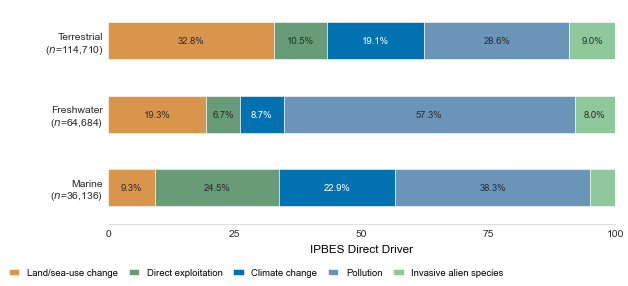

In [9]:
display(core_driver_bar_figure)

## 3. The supplementary figure

Is the IPBES drivers composition changing overtime?
`realm_trends.pdf` = `sfig:realm_trends` in main text.

Analysis done based on same dataset as in earlier figure

- Fig. (a) Plot % of pollution across realms

- Fig. (b) Plot % of articles related to plastic pollution across realms

- Fig. (c) Plot % of direction exploitiaotn across realms


- Where one article carries multiple threats label, it's weight in fractional manner:  \(k\) drivers contributes \(1/k\) to each.

- The plastics denominator is pollution-tagged publications searched using title or abstract text. The case-insensitive regex captures `plastic(s)`, `microplastic(s)`, `nano-plastic(s)`, plastic `debris/waste/litter/particles/fibres/pellets/fragments/pollution`, and marine or anthropogenic `debris/litter`; word boundaries prevent `plasticity` from matching.

- The solid lines in the figure are a 5-year centered rolling mean of the annual values; faint lines/points show the raw annual share. 

In [10]:
nameability_evidence = driver_realm.prepare_pollution_nameability_evidence(
    prepared.evidence,
    corpus_df,
    realm_order=CORE_REALMS,
)
nameability_annual = driver_realm.annual_pollution_nameability_summary(
    nameability_evidence,
    realm_order=CORE_REALMS,
)
outcome_order = [
    "Pollution fractional attention",
    "Plastics within pollution",
    "Direct exploitation fractional attention",
]
print(
    "Core realms:",
    ", ".join(f"{realm} (n={realm_supports[realm]:,})" for realm in CORE_REALMS),
)
print()
endpoints = nameability_annual.loc[
    nameability_annual["publication_year"].isin((START_YEAR, END_YEAR))
]
endpoint_table = (
    endpoints.pivot(index=["outcome", "realm"], columns="publication_year", values="share_pct")
    .reindex(
        pd.MultiIndex.from_product((outcome_order, CORE_REALMS), names=["outcome", "realm"])
    )
    .round(1)
)
endpoint_table.columns = [f"{int(year)} (%)" for year in endpoint_table.columns]
endpoint_table["change_pp"] = (
    endpoint_table[f"{END_YEAR} (%)"] - endpoint_table[f"{START_YEAR} (%)"]
).round(1)
display(endpoint_table)

Core realms: Terrestrial (n=114,710), Freshwater (n=64,684), Marine (n=36,136)



2000 (%)  2025 (%)  \
outcome                                  realm                             
Pollution fractional attention           Terrestrial      35.4      26.9   
                                         Freshwater       62.8      55.8   
                                         Marine           46.9      38.7   
Plastics within pollution                Terrestrial       0.9       9.6   
                                         Freshwater        0.8      12.4   
                                         Marine            0.5      24.0   
Direct exploitation fractional attention Terrestrial      15.2       8.3   
                                         Freshwater        9.2       5.7   
                                         Marine           33.0      20.2   

                                                      change_pp  
outcome                                  realm                   
Pollution fractional attention           Terrestrial       -8.5  
                                         Freshwater        -7.0  
                                         Marine            -8.2  
Plastics within pollution                Terrestrial        8.7  
                                         Freshwater        11.6  
                                         Marine            23.5  
Direct exploitation fractional attention Terrestrial       -6.9  
                                         Freshwater        -3.5  
                                         Marine           -12.8

In [11]:
nameability_figure = driver_realm_plotting.plot_pollution_nameability_trends(
    nameability_annual,
    realm_order=CORE_REALMS,
    realm_names=REALM_NAMES,
    realm_colors=CORE_REALM_COLORS,
    start_year=START_YEAR,
    end_year=END_YEAR,
)
save_figure(
    nameability_figure, REALM_CONFIG["pollution_nameability_figure_filename"]
)
plt.close(nameability_figure)

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_realm_composition/figures/pollution_plastics_exploitation_trends_core_realms.pdf


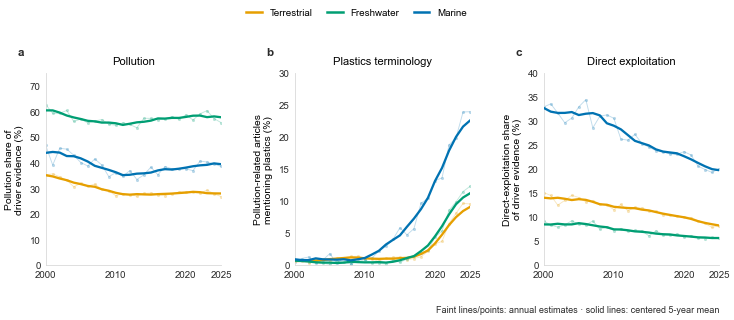

In [12]:
display(nameability_figure)

## 4. Export

The realm article counts and exclusion audit, the core-realm driver composition behind the
manuscript figure, the detailed driver × realm summary (prevalence, LQ, and fractional
share), and the pollution/plastics/exploitation annual series behind the supplementary
figure.

In [13]:
core_driver_composition = driver_summary.pivot(
    index="driver", columns="realm", values="fractional_share_pct"
)[list(CORE_REALMS)]

for table, filename, index in (
    (realm_counts, "realm_article_counts", False),
    (prepared.realm_exclusions, "realm_exclusion_audit", False),
    (core_driver_composition.reset_index(), "core_realm_driver_composition", False),
    (driver_summary, "driver_realm_summary", False),
    (nameability_annual, "realm_trend_annual", False),
):
    save_table(table, filename, index=index)
for path in sorted(FIGURE_DIR.glob("*.pdf")):
    print(path.relative_to(PROJECT_ROOT))

manifest = {
    "result": "03_realm_composition",
    "method_details": {
        "dataset_filters": {
            "direction": REALM_CONFIG["direction"],
            "year_window": f"{START_YEAR}-{END_YEAR} complete publication years",
            "n_direction_filtered": int(n_negative),
            "n_in_window": int(n_in_window),
            "n_outside_window_or_missing_year": int(n_outside_window),
            "realm_filter": (
                "Exactly one core realm (Terrestrial, Freshwater, Marine) per "
                "publication; Not Applicable, All realms, multi-label realm "
                "combinations, and transition/subterranean realms are excluded"
            ),
            "realm_exclusions": {
                str(row["realm_category"]): int(row["n_documents"])
                for _, row in prepared.realm_exclusions.iterrows()
            },
            "driver_filter": "At least one usable IPBES L1 driver label",
            "n_excluded_no_driver": int(n_driver_excluded),
            "n_final_publications": int(n_realm_final),
            "realm_supports": {
                realm: int(realm_supports[realm]) for realm in CORE_REALMS
            },
        },
        "panel_driver_composition": {
            "grain": "UT x realm x distinct IPBES L1 driver",
            "n_publications": int(n_driver_final),
            "n_multi_driver_publications": int(n_multi_driver),
            "n_publication_driver_assignments": int(n_driver_tags),
            "n_driver_classes": int(len(DRIVER_ORDER)),
            "fractional_weight_formula": (
                "w_i,d = 1 / k_i, where k_i is the number of distinct IPBES L1 "
                "drivers assigned to publication i; sum_d(w_i,d) = 1"
            ),
            "share_formula": (
                "share_d,r (%) = 100 * sum_i(w_i,d) / N_r, where N_r is the number "
                "of unique publications in realm r"
            ),
        },
        "panel_pollution_plastics_exploitation_trends": {
            "scope": (
                "Same direction/year/realm/driver-filtered publications as the "
                "driver-composition panel"
            ),
            "pollution_and_exploitation_attention_formula": (
                "share_r,y (%) = 100 * sum_i(w_i,d) / N_r,y for d in {Pollution, "
                "Direct Exploitation and Resource Extraction}, same 1/k weighting "
                "as the driver-composition panel"
            ),
            "plastics_within_pollution_formula": (
                "share_r,y (%) = 100 * n_plastics_mention / n_pollution_and_text_available "
                "(unweighted document count, not fractional)"
            ),
            "plastics_mention_source": (
                "Precomputed at data-processing time "
                "(notebooks/data_processing/04_dataset.ipynb, via "
                "evidence_corpus_prep.DEFAULT_PLASTICS_PATTERN) from title + "
                "abstract text with a case-insensitive regex; persisted as the "
                "text_available/plastics_mention columns on dataset.parquet so "
                "this notebook never loads abstract text"
            ),
            "figure_smoothing": (
                "Solid lines are a 5-year centered rolling mean of the annual "
                "values; faint lines/points show the raw annual share"
            ),
            "exported_endpoint_values": (
                f"Raw {START_YEAR} and {END_YEAR} annual share_pct values as "
                "quoted in the manuscript; no trend model is fitted"
            ),
            "outcomes": outcome_order,
        },
    },
    "artifacts": {
        "csv/realm_article_counts.csv": (
            "Unique-publication counts per core realm after all dataset filters."
        ),
        "csv/realm_exclusion_audit.csv": (
            "Counts of direction/year-filtered publications excluded at the "
            "realm-filtering step, by exclusion reason."
        ),
        "csv/core_realm_driver_composition.csv": (
            "IPBES L1 driver x core-realm fractional composition (%) behind the "
            "manuscript figure."
        ),
        "csv/driver_realm_summary.csv": (
            "Full driver x realm summary: prevalence, location quotient, and "
            "fractional share."
        ),
        "csv/realm_trend_annual.csv": (
            "Annual pollution / plastics-within-pollution / direct-exploitation "
            "shares per core realm behind the supplementary figure."
        ),
        "figures/l1_driver_composition_core_realms.pdf": (
            "Manuscript figure: IPBES L1 driver composition across the three "
            "core realms."
        ),
        "figures/pollution_plastics_exploitation_trends_core_realms.pdf": (
            "Supplementary figure: pollution, plastics-within-pollution, and "
            "direct-exploitation attention trends across core realms, "
            f"{START_YEAR}-{END_YEAR}."
        ),
    },
}
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2) + "\n", encoding="utf-8"
)
print(manifest_path.relative_to(PROJECT_ROOT))

Saved: notebooks/results/outputs/03_realm_composition/csv/realm_article_counts.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/realm_exclusion_audit.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/core_realm_driver_composition.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/driver_realm_summary.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/realm_trend_annual.csv
notebooks/results/outputs/03_realm_composition/figures/l1_driver_composition_core_realms.pdf
notebooks/results/outputs/03_realm_composition/figures/pollution_plastics_exploitation_trends_core_realms.pdf
notebooks/results/outputs/03_realm_composition/manifest.json
